# Diabetes 資料集 — 機器學習期末實作

## 1. 載入與觀察資料

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 2. 資料視覺化

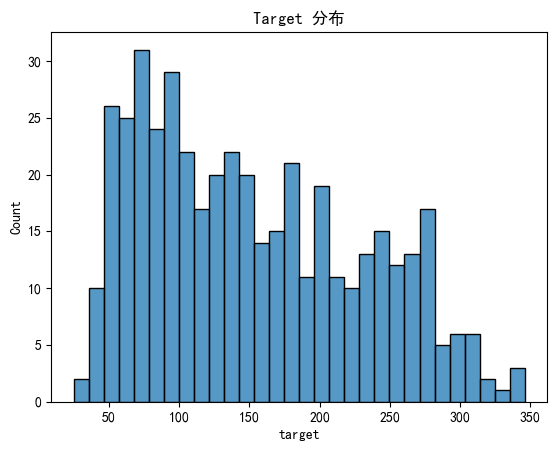

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #设置负号正常显示
sns.histplot(df['target'], bins=30)
plt.title('Target 分布')
plt.show()

## 3. 特徵標準化與資料切分

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(diabetes.data)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, diabetes.target, test_size=0.2, random_state=42)

## 4. 線性回歸訓練與評估

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.4526027629719195
MSE: 2900.193628493482


## 5. 使用 Ridge 調參

In [5]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
param_grid = {'alpha': [0.1, 1.0, 10.0]}
ridge = GridSearchCV(Ridge(), param_grid, cv=5)
ridge.fit(X_scaled, diabetes.target)
print("Best Ridge Params:", ridge.best_params_)
print("Best CV Score:", ridge.best_score_)

Best Ridge Params: {'alpha': 0.1}
Best CV Score: 0.4823254749935776


## 6. PCA 可視化

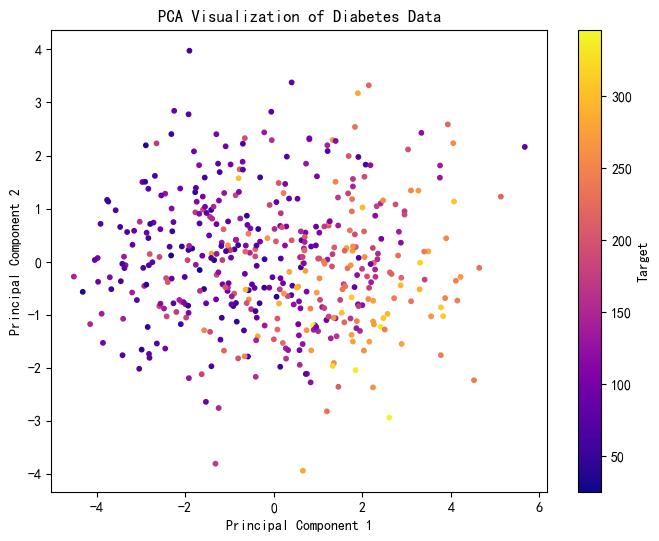

In [6]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=diabetes.target, cmap='plasma', s=10)
plt.colorbar(label='Target')
plt.title('PCA Visualization of Diabetes Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()